In [1]:
print('Hello World')

Hello World


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [29]:
df = pd.read_csv("RestaurantVisitors.csv")

In [3]:
df.head(10)

,date,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
0,1/1/2016,Friday,1,New Year's Day,65.0,25.0,67.0,139.0,296.0
1,1/2/2016,Saturday,0,na,24.0,39.0,43.0,85.0,191.0
2,1/3/2016,Sunday,0,na,24.0,31.0,66.0,81.0,202.0
3,1/4/2016,Monday,0,na,23.0,18.0,32.0,32.0,105.0
4,1/5/2016,Tuesday,0,na,2.0,15.0,38.0,43.0,98.0
5,1/6/2016,Wednesday,0,na,9.0,11.0,22.0,41.0,83.0
6,1/7/2016,Thursday,0,na,15.0,6.0,18.0,30.0,69.0
7,1/8/2016,Friday,0,na,79.0,32.0,22.0,16.0,149.0
8,1/9/2016,Saturday,0,na,44.0,44.0,47.0,99.0,234.0
9,1/10/2016,Sunday,0,na,26.0,43.0,49.0,94.0,212.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          517 non-null    str    
 1   weekday       517 non-null    str    
 2   holiday       517 non-null    int64  
 3   holiday_name  517 non-null    str    
 4   rest1         478 non-null    float64
 5   rest2         478 non-null    float64
 6   rest3         478 non-null    float64
 7   rest4         478 non-null    float64
 8   total         478 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 36.5 KB


In [5]:
df.isnull().sum()

date             0
weekday          0
holiday          0
holiday_name     0
rest1           39
rest2           39
rest3           39
rest4           39
total           39
dtype: int64

In [30]:
df['date'] = pd.to_datetime(df['date'])

In [31]:
df = df[['date', 'total']].rename(columns={'date': 'ds', 'total': 'y'})

In [32]:
df = df.dropna(subset=['y'])

In [33]:
df = df.sort_values('ds').reset_index(drop=True)

In [34]:
df.head(10)

,ds,y
0,2016-01-01,296.0
1,2016-01-02,191.0
2,2016-01-03,202.0
3,2016-01-04,105.0
4,2016-01-05,98.0
5,2016-01-06,83.0
6,2016-01-07,69.0
7,2016-01-08,149.0
8,2016-01-09,234.0
9,2016-01-10,212.0


In [35]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print('Training rows :', len(train_df))
print('Testing rows :', len(test_df))

Training rows : 382
Testing rows : 96


In [36]:
model = Prophet()
model.fit(train_df)

22:46:26 - cmdstanpy - INFO - Chain [1] start processing
22:46:26 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
future = test_df[['ds']].copy()
forecast = model.predict(future)

In [38]:
results = test_df.merge(forecast[['ds', 'yhat']], on='ds', how='left')
results.head()

,ds,y,yhat
0,2017-01-17,103.0,97.921479
1,2017-01-18,100.0,99.247779
2,2017-01-19,70.0,106.331940
3,2017-01-20,125.0,153.453645
4,2017-01-21,182.0,233.413526


In [39]:
actual = results['y'].to_numpy()
predicted = results['yhat'].to_numpy()

rmse = np.sqrt(np.mean((actual - predicted) ** 2))
print('RMSE : ',rmse)

RMSE :  32.13028571222117


In [40]:
actual = results['y'].to_numpy()
predicted = results['yhat'].to_numpy()

non_zero_mask = actual != 0
mape = np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])) * 100

print('MAPE : ',mape)

MAPE :  22.807999827917193


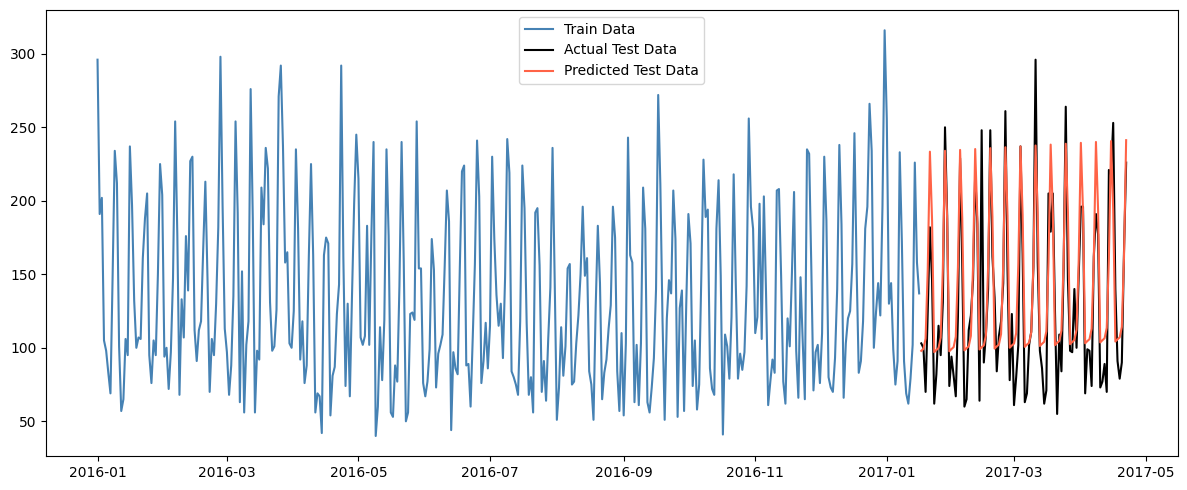

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(train_df['ds'], train_df['y'], label='Train Data', color='steelblue')
plt.plot(test_df['ds'], test_df['y'], label='Actual Test Data', color='black')
plt.plot(results['ds'], results['yhat'], label='Predicted Test Data', color='tomato')
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
df2 = pd.read_csv("RestaurantVisitors.csv")

In [46]:
df2.head(10)

,date,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
0,1/1/2016,Friday,1,New Year's Day,65.0,25.0,67.0,139.0,296.0
1,1/2/2016,Saturday,0,na,24.0,39.0,43.0,85.0,191.0
2,1/3/2016,Sunday,0,na,24.0,31.0,66.0,81.0,202.0
3,1/4/2016,Monday,0,na,23.0,18.0,32.0,32.0,105.0
4,1/5/2016,Tuesday,0,na,2.0,15.0,38.0,43.0,98.0
5,1/6/2016,Wednesday,0,na,9.0,11.0,22.0,41.0,83.0
6,1/7/2016,Thursday,0,na,15.0,6.0,18.0,30.0,69.0
7,1/8/2016,Friday,0,na,79.0,32.0,22.0,16.0,149.0
8,1/9/2016,Saturday,0,na,44.0,44.0,47.0,99.0,234.0
9,1/10/2016,Sunday,0,na,26.0,43.0,49.0,94.0,212.0


In [61]:
initial = df2[['date', 'total']].copy()

In [62]:
initial['date'] = pd.to_datetime(df2['date'])

In [63]:
initial = initial.dropna(subset=['total']).sort_values('date').reset_index(drop=True)
initial.head()

,date,total
0,2016-01-01,296.0
1,2016-01-02,191.0
2,2016-01-03,202.0
3,2016-01-04,105.0
4,2016-01-05,98.0


In [64]:

# lag_1 means previous day's visitors
initial['lag_1'] = initial['total'].shift(1)
initial['rolling_mean_7'] = initial['total'].shift(1).rolling(window=7).mean()

initial.head(10)

,date,total,lag_1,rolling_mean_7
0,2016-01-01,296.0,NaN,NaN
1,2016-01-02,191.0,296.0,NaN
2,2016-01-03,202.0,191.0,NaN
3,2016-01-04,105.0,202.0,NaN
4,2016-01-05,98.0,105.0,NaN
5,2016-01-06,83.0,98.0,NaN
6,2016-01-07,69.0,83.0,NaN
7,2016-01-08,149.0,69.0,149.142857
8,2016-01-09,234.0,149.0,128.142857
9,2016-01-10,212.0,234.0,134.285714


In [66]:
final_df = initial[['date', 'total']].rename(columns={'date': 'ds', 'total': 'y'})

# Create a holidays table for Prophet using the holiday information in the dataset
holidays_df = df2[df2['holiday'] == 1][['date', 'holiday_name']].copy()
holidays_df['date'] = pd.to_datetime(holidays_df['date'])
holidays_df = holidays_df.rename(columns={'date': 'ds', 'holiday_name': 'holiday'})
holidays_df = holidays_df.drop_duplicates().reset_index(drop=True)

print('Number of holiday rows used in Prophet:', len(holidays_df))
final_df.head()

Number of holiday rows used in Prophet: 35


,ds,y
0,2016-01-01,296.0
1,2016-01-02,191.0
2,2016-01-03,202.0
3,2016-01-04,105.0
4,2016-01-05,98.0


In [67]:
split_index = int(len(final_df) * 0.80)

train_df = final_df.iloc[:split_index].copy()
test_df = final_df.iloc[split_index:].copy()

print('Training rows :', len(train_df))
print('Testing rows :', len(test_df))


Training rows : 382
Testing rows : 96


In [68]:
model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model.fit(train_df)

23:16:15 - cmdstanpy - INFO - Chain [1] start processing
23:16:15 - cmdstanpy - INFO - Chain [1] done processing


In [69]:
future = test_df[['ds']].copy()
forecast = model.predict(future)

results = test_df.merge(forecast[['ds', 'yhat']], on='ds', how='left')
results.head()

,ds,y,yhat
0,2017-01-17,103.0,81.806538
1,2017-01-18,100.0,78.305191
2,2017-01-19,70.0,80.209867
3,2017-01-20,125.0,125.075046
4,2017-01-21,182.0,214.815514


In [70]:
actual = results['y'].to_numpy()
predicted = results['yhat'].to_numpy()

rmse = np.sqrt(np.mean((actual - predicted) ** 2))
print('RMSE : ',rmse)

RMSE :  25.520033535913896


In [71]:
actual = results['y'].to_numpy()
predicted = results['yhat'].to_numpy()

non_zero_mask = actual != 0
mape = np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])) * 100
print('MAPE : ',mape)


MAPE :  16.444324974434963


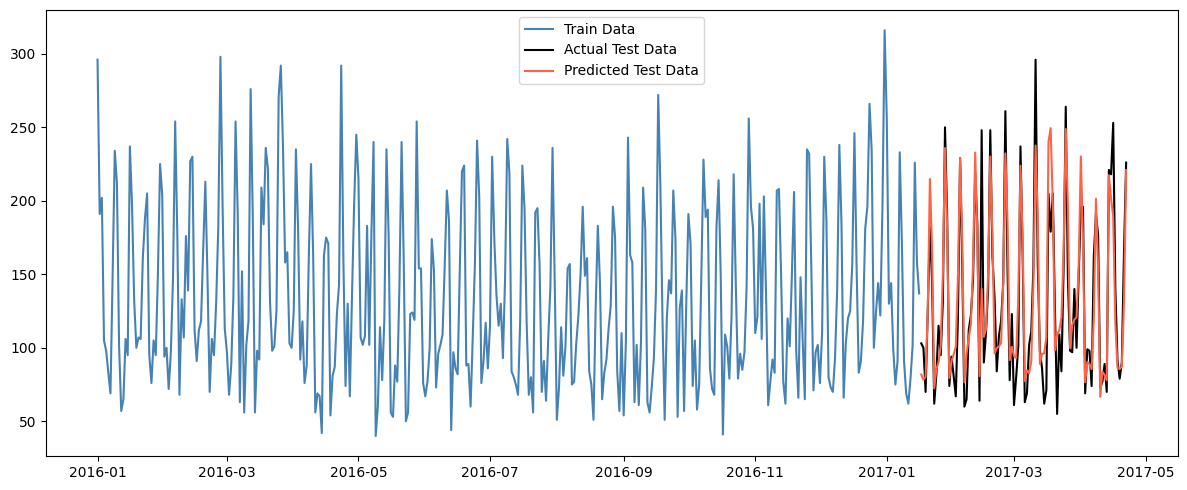

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(train_df['ds'], train_df['y'], label='Train Data', color='steelblue')
plt.plot(test_df['ds'], test_df['y'], label='Actual Test Data', color='black')
plt.plot(results['ds'], results['yhat'], label='Predicted Test Data', color='tomato')
plt.legend()
plt.tight_layout()
plt.show()